# Итоговая работа по Scientific programming
___
___
**Студент:** Рштуни Владислав Дмитриевич<br>
**Группа:** 3825М1сФИ1

___
## Цель работы
Построить и сравнить модели машинного обучения для бинарной классификации наличия сердечно-сосудистых заболеваний на основе клинических параметров пациента, определить наиболее значимые признаки и оптимизировать метрики качества (F1-score, ROC-AUC), значимые для медицинской диагностики.

___
## Используемый датасет

[Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease)

**Предметная область:** Здравоохранение и медицина

**Связанные задачи:** Классификация

**Типы данных признаков:** Категориальное, целое число, вещественное число

**Количество признаков:** 13 + целевая переменная

**Количество данных:** 303 строки
___

**About Dataset**
>This database contains 76 attributes, but all published experiments refer to using a subset of 14 of them.  In particular, the Cleveland database is the only one that has been used by ML researchers to date.  The "goal" field refers to the presence of heart disease in the patient.  It is integer valued from 0 (no presence) to 4. Experiments with the Cleveland database have concentrated on simply attempting to distinguish presence (values 1,2,3,4) from absence (value 0).  
>   
>The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.
>
>One file has been "processed", that one containing the Cleveland database.  All four unprocessed files also exist in this directory.
>
>To see Test Costs (donated by Peter Turney), please see the folder "Costs" 

___
## План работы
- Описание задачи
- Загрузка данных
- Разведочный анализ данных (EDA)
- Предобработка данных
- Разбиение на обучающую и тестовую выборки
- Обучение моделей
- Обучение настроенных моделей
- Вывод результатов всех моделей
- Сравнение моделей до и после настройки
- Анализ важности признаков
- Детальный анализ лучшей модели
- Детальный анализ лучших моделей

___
___

# 0. Описание атрибутов
___

В табличном ввиде:
| №  | Признак    | Тип         | Not-Null    | Описание                                                                                                                             |
|----|------------|-------------|-------------|--------------------------------------------------------------------------------------------------------------------------------------|
| 0  | `age`      | Integer     | 303 (100%)  |  Возраст в годах.                                                                                                                    |
| 1  | `sex`      | Categorical | 303 (100%)  | Пол пациента: 1 = мужчина; 0 = женщина.                                                                                              |
| 2  | `cp`       | Categorical | 303 (100%)  | Тип боли в груди (chest pain): 1 = типичная стенокардия; 2 = атипичная стенокардия; 3 = неангинальная боль; 4 = асимптоматично.      |
| 3  | `trestbps` | Integer     | 303 (100%)  | Артериальное давление в состоянии покоя (на момент поступления в госпиталь) в мм рт. ст.                                             |
| 4  | `chol`     | Integer     | 303 (100%)  | Уровень сывороточного холестерина в мг/дл.                                                                                           |
| 5  | `fbs`      | Categorical | 303 (100%)  | Уровень сахара в крови натощак > 120 мг/дл: 1 = истина (да); 0 = ложь (нет).                                                                                                                                                                               |
| 6  | `restecg`  | Categorical | 303 (100%)  | Результаты электрокардиографии в покое: 0 = норма; 1 = наличие аномалии ST-T; 2 = гипертрофия левого желудочка.                                                                                                                                                                           |
| 7  | `thalach`  | Integer     | 303 (100%)  | Максимальная достигнутая частота сердечных сокращений (пульс).                                                                       |
| 8  | `exang`    | Categorical | 303 (100%)  | Стенокардия, вызванная физической нагрузкой: 1 = да; 0 = нет.                                                                        |
| 9  | `oldpeak`  | Integer     | 303 (100%)  | Депрессия сегмента ST, вызванная физической нагрузкой, относительно состояния покоя ("старый пик").                                                                                                                                                                               |
| 10 | `slope`    | Categorical | 303 (100%)  | Наклон пикового сегмента ST при нагрузке: 1 = восходящий; 2 = плоский; 3 = нисходящий.                                                                                                                                                                          |
| 11 | `ca`       | Integer     | 299 (98.7%) | Количество основных сосудов (0-3), окрашенных при флюороскопии.                                                                      |
| 12 | `thal`     | Categorical | 301 (99.3%) | Результат теста с таллием (талассемия): 3 = нормальное кровоснабжение; 6 = фиксированный дефект; 7 = обратимый дефект.                                                                                                                                                                              | 
| 13 | `num`      | Integer     | 303 (100%)  | Целевая переменная. Диагноз болезни сердца: 0 = отсутствие (<50% сужения сосуда); 1,2,3,4 = наличие болезни (разная степень).                                                                                                                                                                            |



___
___

# Подключение библиотек

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Машинное обучение
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, OrdinalEncoder, 
                                   FunctionTransformer, PowerTransformer)
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

# Модели
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Метрики
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score)

# Утилиты
import time

DATASET_ID = 45

___
___

# 1. Загрузка данных
___
Загружаем датасет из набора данных из Репозитория машинного обучения UC Irvine (UCI ML Repository) с помощью функции ```fetch_ucirepo```. 

Датасет имеет ```id = 45```

In [80]:
from ucimlrepo import fetch_ucirepo
heart_disease = fetch_ucirepo(id=DATASET_ID)

X = heart_disease.data.features 
y = heart_disease.data.targets

print("=" * 80)
print("1. АНАЛИЗ ДАТАСЕТА HEART DISEASE")
print("=" * 80)
print(f"\n1.1. ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ:")
print("-" * 40)
print(f"    Размер признаков: {X.shape[0]} строки, {X.shape[1]} столбцов")
print(f"    Целевая переменная: {y.shape[0]} строки, {y.shape[1]} столбец")

df = X.copy() 
df['num'] = y

print(f"\n1.2. РАСПРЕДЕЛЕНИЕ ИСХОДНЫХ КЛАССОВ (5 классов):")
print("-" * 40)
target_counts = df['num'].value_counts().sort_index()
for i in range(5):
    count = target_counts.get(i, 0)
    percentage = (count / len(df)) * 100
    if i == 0:
        print(f"   Класс {i} (нет болезни): {count} записей ({percentage:.1f}%)")
    else:
        print(f"   Класс {i} (стадия {i}): {count} записей ({percentage:.1f}%)")

# Преобразуем целевую переменную в bool вид (0 - здоров, 1 - болен)
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

print(f"\n1.3. БИНАРНАЯ КЛАССИФИКАЦИЯ:")
print("-" * 40)
print(f"    Здоровые (0): {(df['num'] == 0).sum()} ({100*(df['num'] == 0).mean():.1f}%)")
print(f"    Больные (1): {(df['num'] == 1).sum()} ({100*(df['num'] == 1).mean():.1f}%)")

1. АНАЛИЗ ДАТАСЕТА HEART DISEASE

1.1. ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ:
----------------------------------------
    Размер признаков: 303 строки, 13 столбцов
    Целевая переменная: 303 строки, 1 столбец

1.2. РАСПРЕДЕЛЕНИЕ ИСХОДНЫХ КЛАССОВ (5 классов):
----------------------------------------
   Класс 0 (нет болезни): 164 записей (54.1%)
   Класс 1 (стадия 1): 55 записей (18.2%)
   Класс 2 (стадия 2): 36 записей (11.9%)
   Класс 3 (стадия 3): 35 записей (11.6%)
   Класс 4 (стадия 4): 13 записей (4.3%)

1.3. БИНАРНАЯ КЛАССИФИКАЦИЯ:
----------------------------------------
    Здоровые (0): 164 (54.1%)
    Больные (1): 139 (45.9%)


___
___
# 2. Разведочный анализ данных 

___
Проводим полный EDA:
- Проверяем типы данных в датасете;
- Анализ пропущенных значений;
- Анализ числовых признаков (Распределение числовых признаков, Распределение целевой переменной);
- Анализ категориальных признаков;
- Корреляционная матрица.


2. РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)

2.1. ТИПЫ ДАННЫХ СТОЛБЦОВ ДАТАСЕТА:
----------------------------------------
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

2.2. ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:
----------------------------------------
ca: 4 пропущенных (1.32%)
thal: 2 пропущенных (0.66%)

2.5. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ:
----------------------------------------


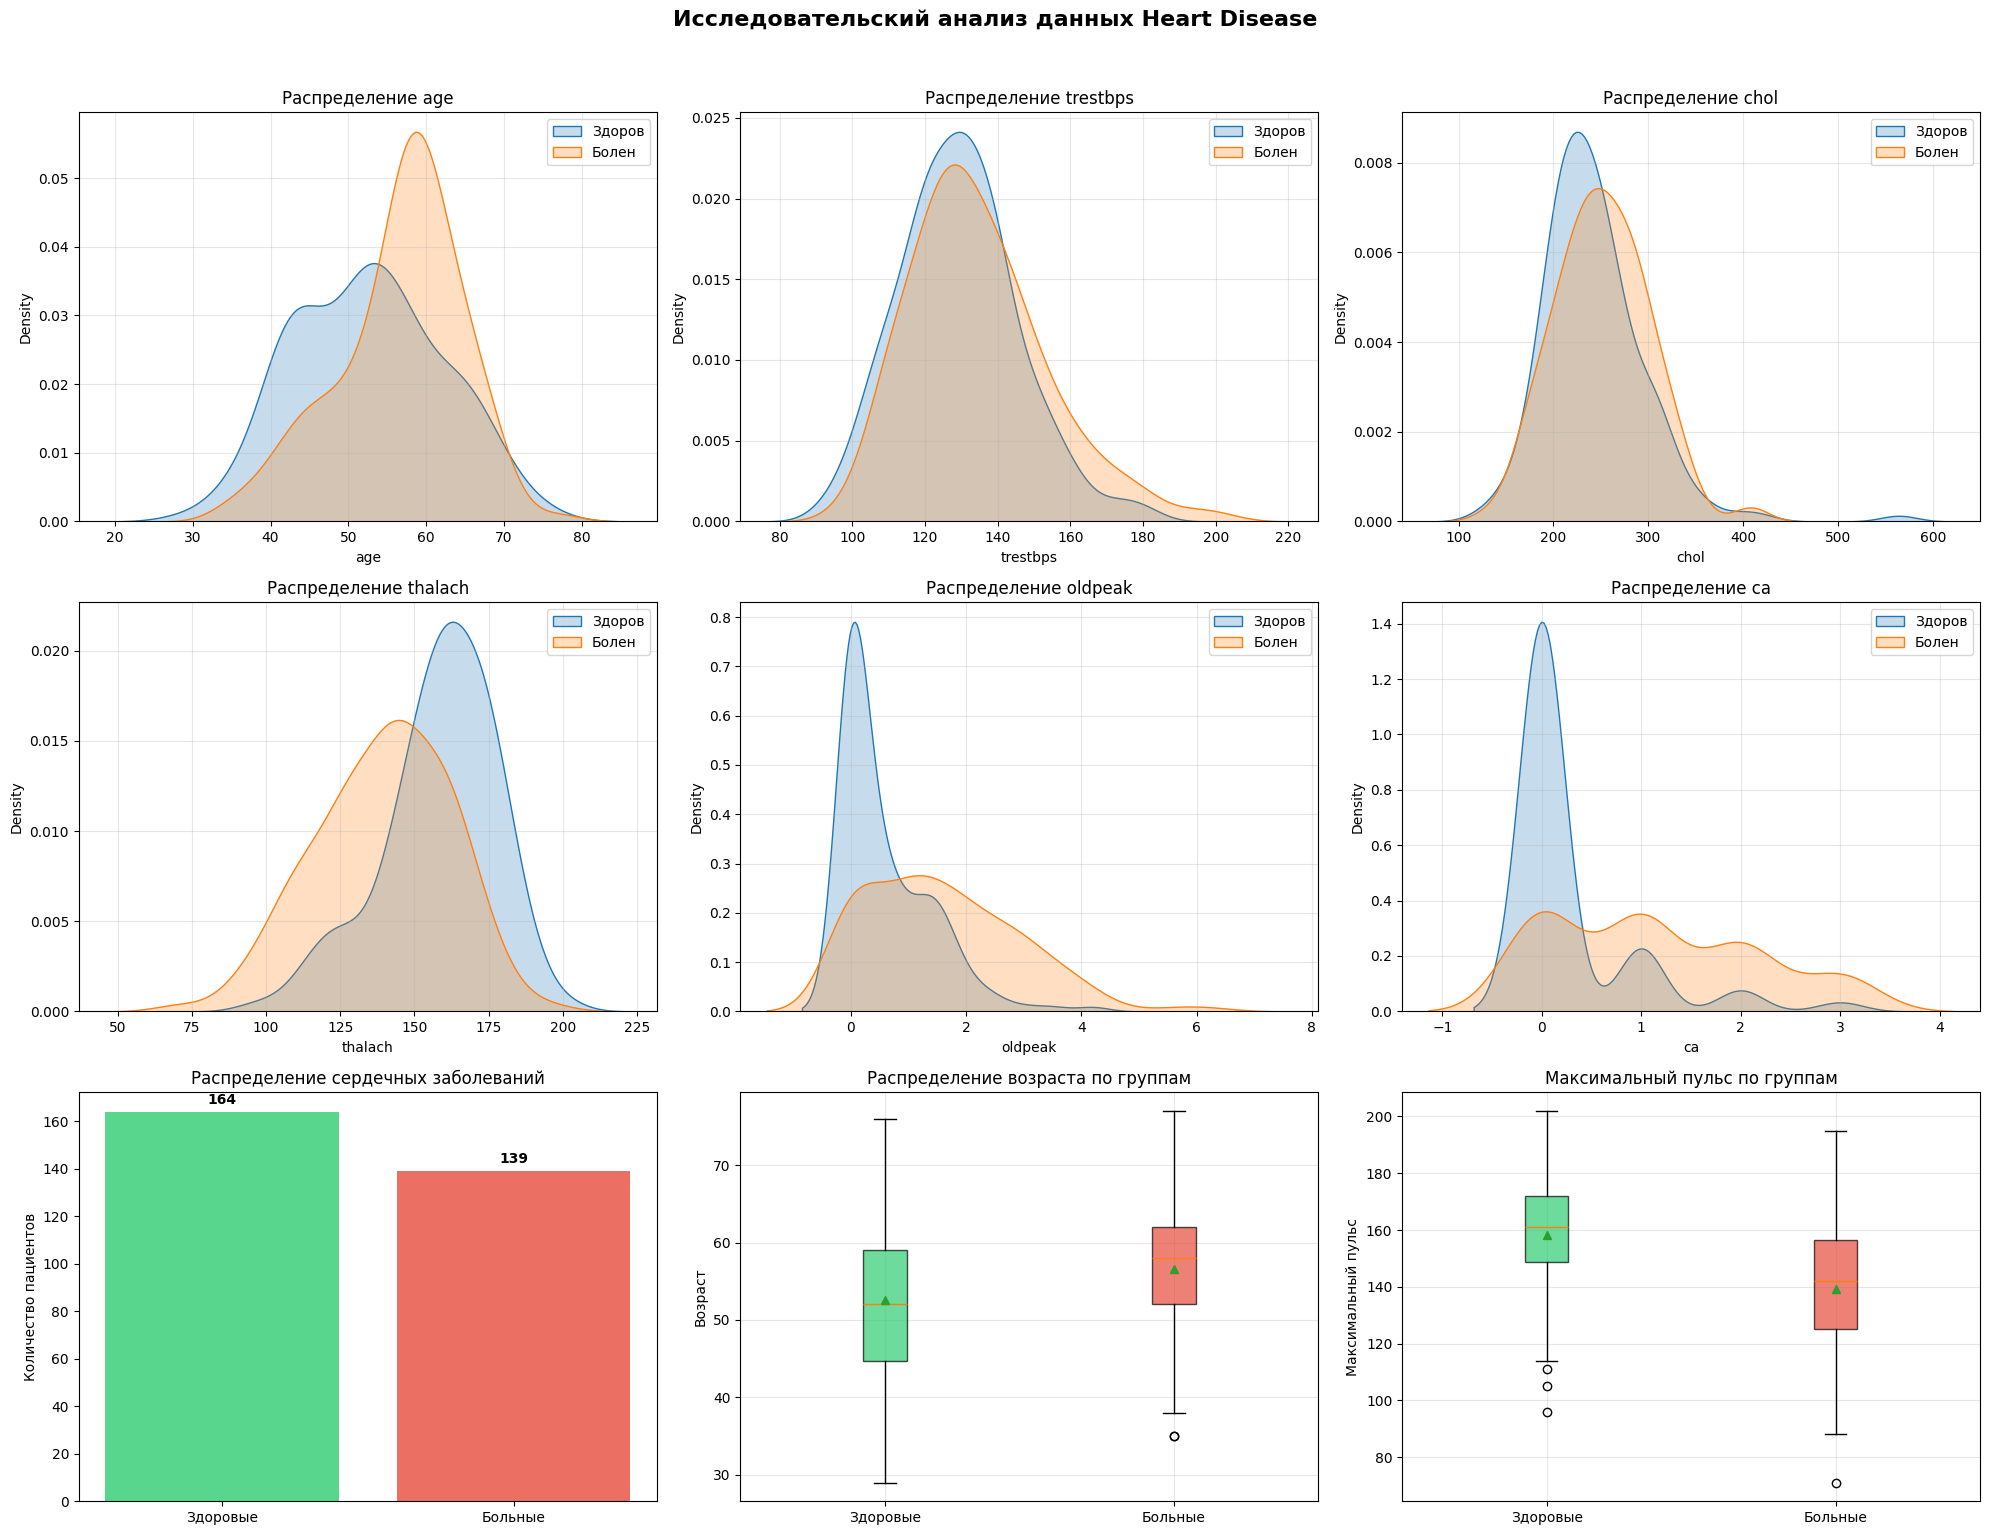


2.6. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:
----------------------------------------


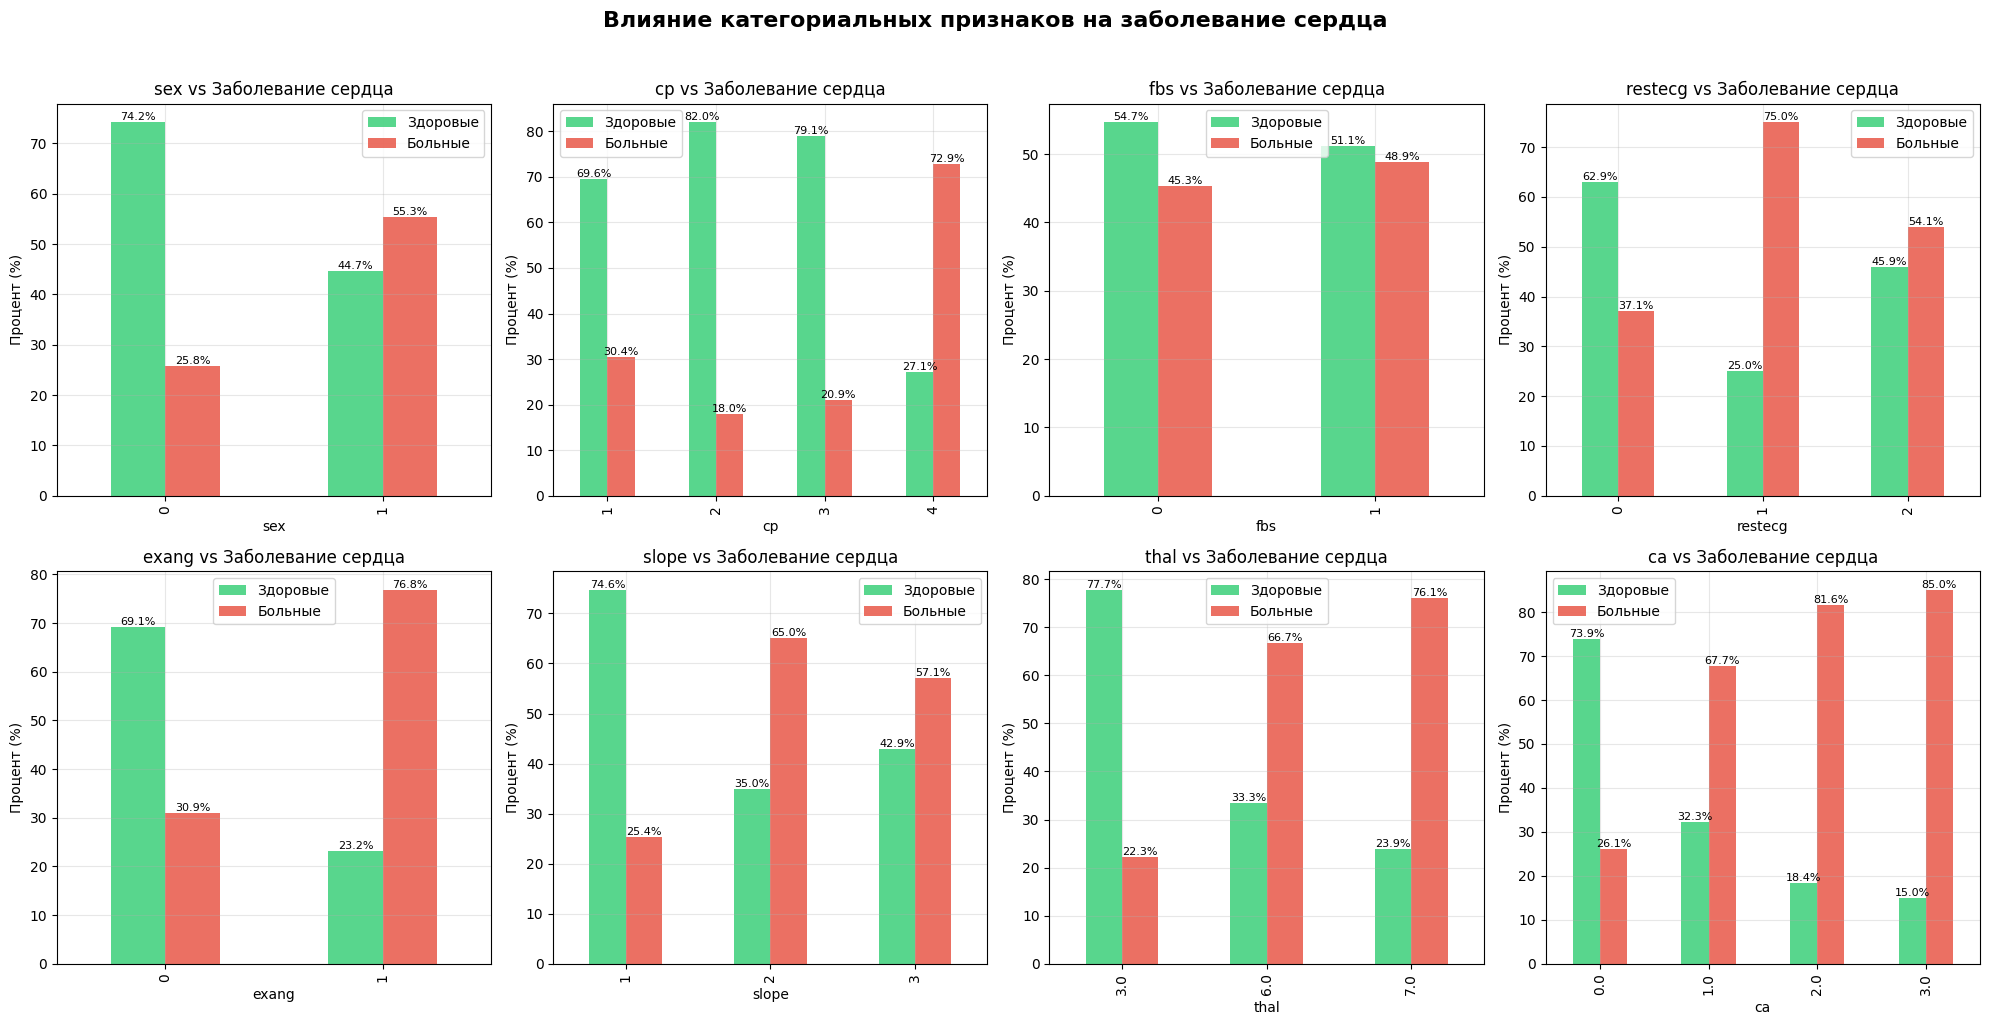

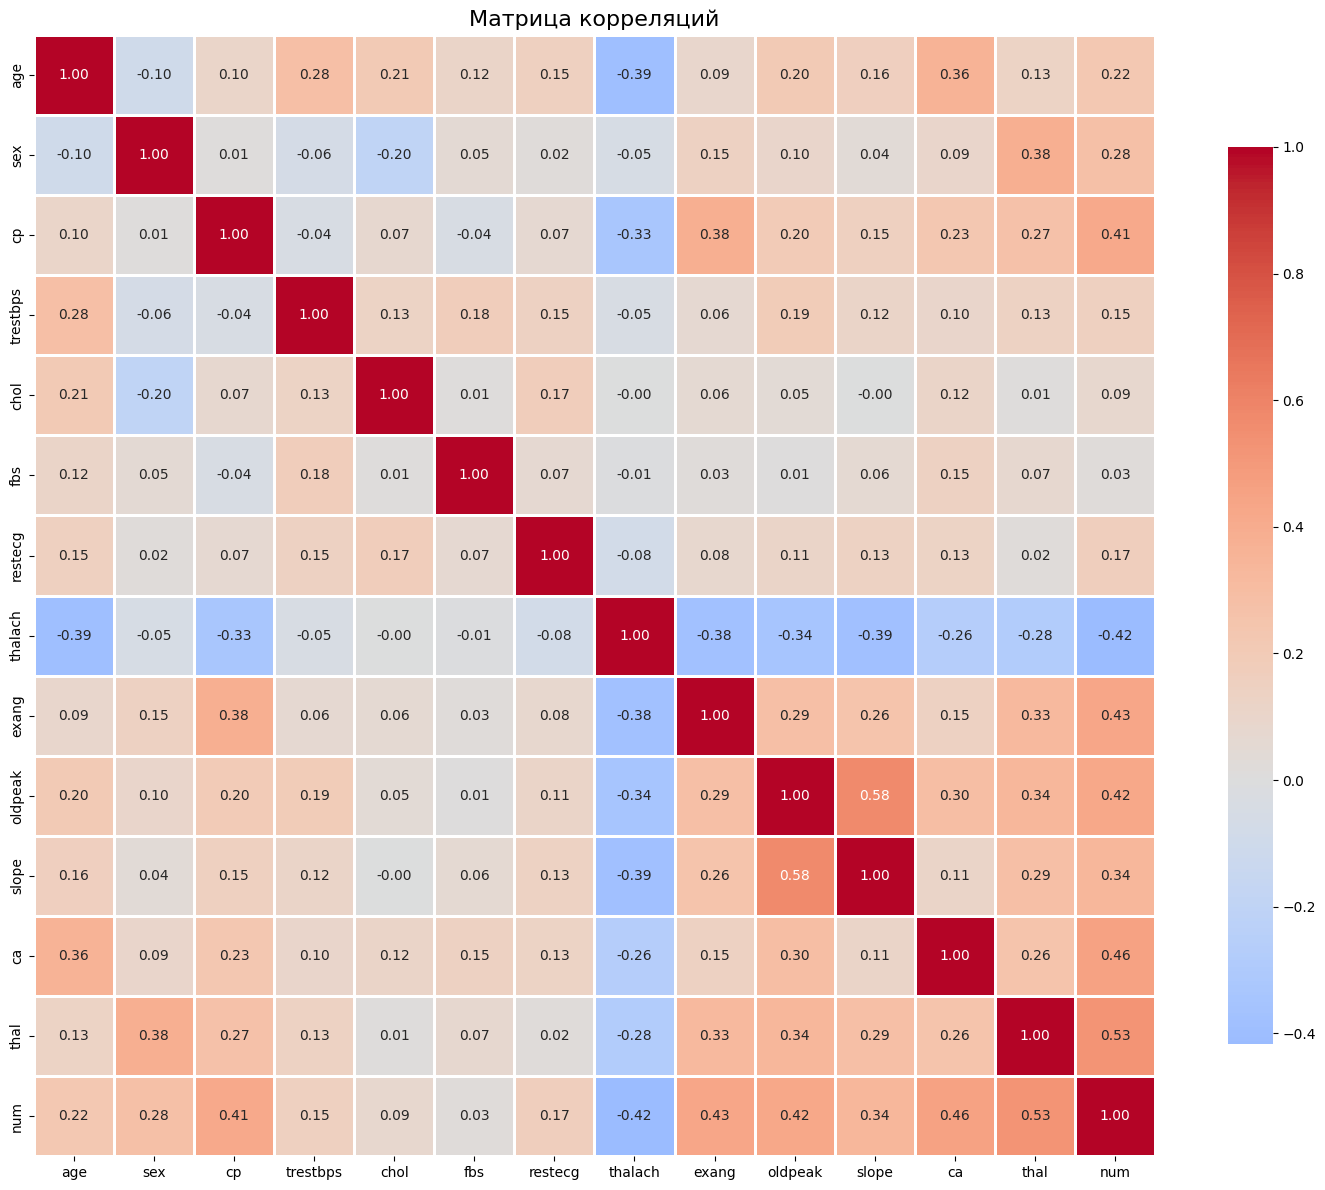

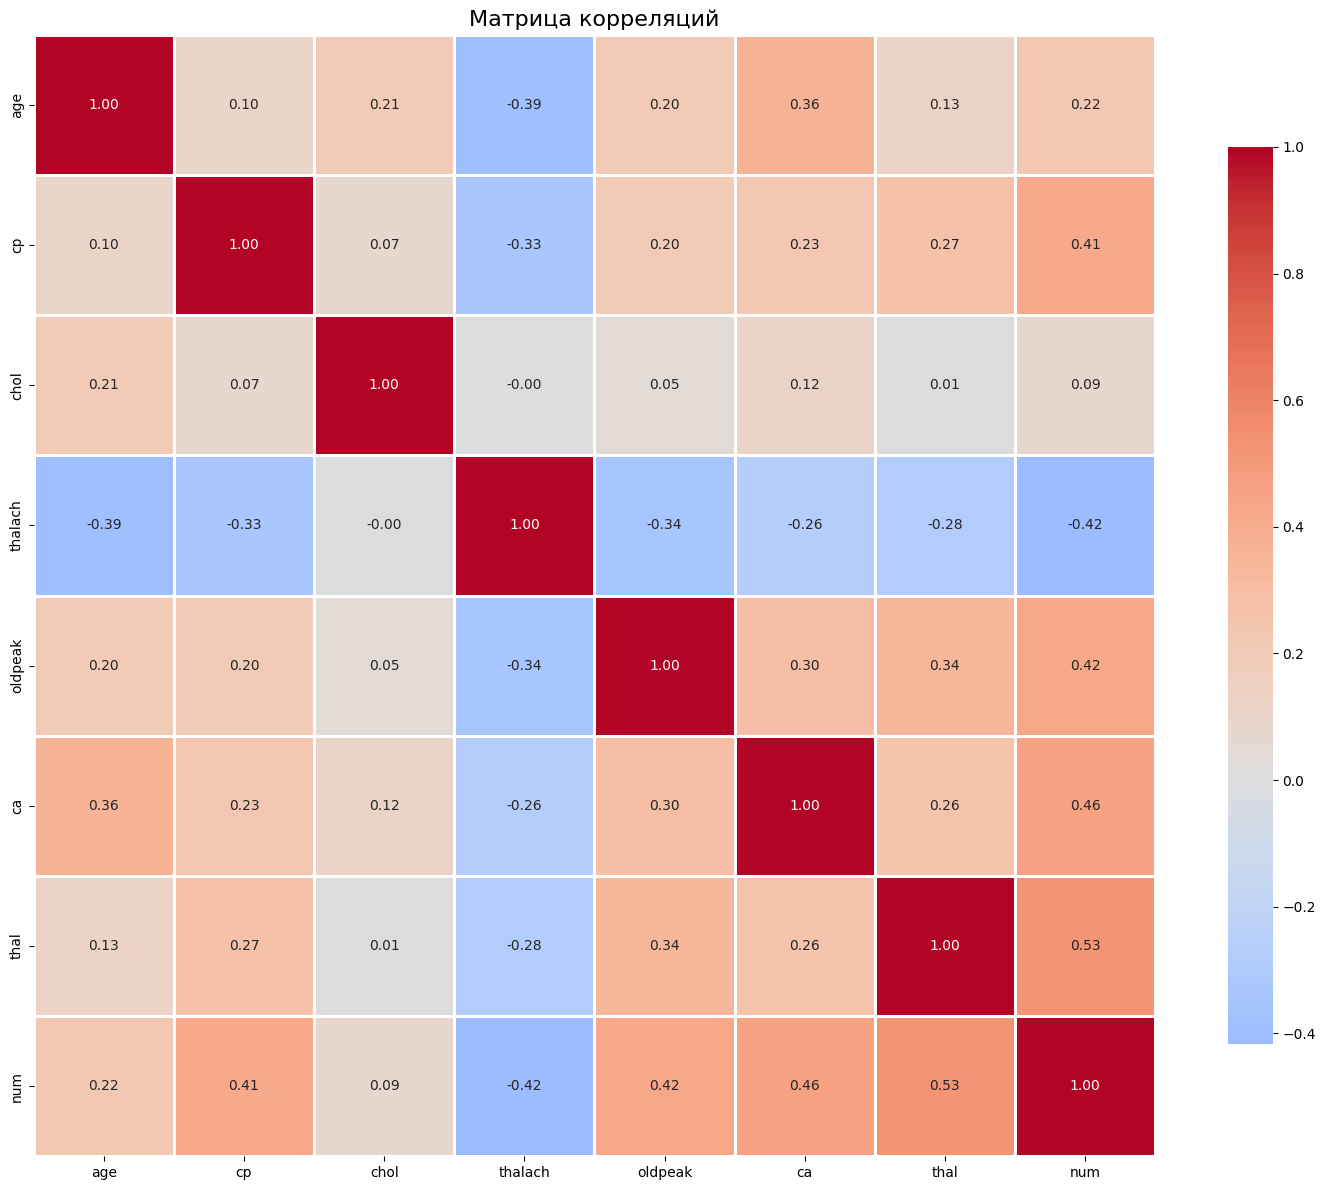

In [81]:
print(f"\n" + "=" * 80)
print("2. РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)")
print("=" * 80)

print(f"\n2.1. ТИПЫ ДАННЫХ СТОЛБЦОВ ДАТАСЕТА:")
print("-" * 40)
print(df.dtypes)

print("\n2.2. ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:")
print("-" * 40)
missing_data = df.isnull().sum()
missing_percent = (missing_data[missing_data > 0] / len(df)) * 100

if len(missing_percent) > 0:
    for col in missing_percent.index:
        print(f"{col}: {missing_data[col]} пропущенных ({missing_percent[col]:.2f}%)")
else:
    print("\nПропущенных значений не обнаружено")

# Числовые признаки
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
# Категориальные признаки
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

print("\n2.5. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ:")
print("-" * 40)
fig = plt.figure(figsize=(20, 15))
# Распределение числовых признаков
for i, feature in enumerate(numeric_features, 1):
    ax = plt.subplot(3, 3, i)
    # Разделяем по целевому классу
    for target in [0, 1]:
        subset = df[df['num'] == target][feature].dropna()
        sns.kdeplot(subset, label=f"{'Здоров' if target == 0 else 'Болен'}", ax=ax, fill=True)
    ax.set_title(f'Распределение {feature}')
    ax.set_xlabel(feature)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Распределение целевой переменной
ax = plt.subplot(3, 3, 7)
bars = ax.bar(['Здоровые', 'Больные'], 
              df['num'].value_counts().values,
              color=['#2ecc71', '#e74c3c'], alpha=0.8)
ax.set_title('Распределение сердечных заболеваний')
ax.set_ylabel('Количество пациентов')
# Добавляем значения на столбцы
for bar, count in zip(bars, df['num'].value_counts().values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(count), ha='center', va='bottom', fontweight='bold')

# Возраст vs болезнь сердца
ax = plt.subplot(3, 3, 8)
age_data = [df[df['num'] == 0]['age'].dropna(),
            df[df['num'] == 1]['age'].dropna()]
box = ax.boxplot(age_data, labels=['Здоровые', 'Больные'], 
                 patch_artist=True, showmeans=True)
# Цвета для боксов
colors = ['#2ecc71', '#e74c3c']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Распределение возраста по группам')
ax.set_ylabel('Возраст')
ax.grid(True, alpha=0.3)

# Максимальный пульс vs болезнь сердца
ax = plt.subplot(3, 3, 9)
thalach_data = [df[df['num'] == 0]['thalach'].dropna(),
                df[df['num'] == 1]['thalach'].dropna()]
box = ax.boxplot(thalach_data, labels=['Здоровые', 'Больные'], 
                 patch_artist=True, showmeans=True)
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Максимальный пульс по группам')
ax.set_ylabel('Максимальный пульс')
ax.grid(True, alpha=0.3)

plt.suptitle('Исследовательский анализ данных Heart Disease', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n2.6. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:")
print("-" * 40)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

tmp_categorical_features = categorical_features.copy() + ['ca']

for i, feature in enumerate(tmp_categorical_features):
    if feature in df.columns:
        # Создаем таблицу сопряженности
        cross_tab = pd.crosstab(df[feature], df['num'], 
                                normalize='index') * 100
        
        # Визуализация
        cross_tab.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], alpha=0.8)
        axes[i].set_title(f'{feature} vs Заболевание сердца')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Процент (%)')
        axes[i].legend(['Здоровые', 'Больные'])
        axes[i].grid(True, alpha=0.3)
        
        # Добавляем аннотации
        for container in axes[i].containers:
            axes[i].bar_label(container, fmt='%.1f%%', fontsize=8)

plt.suptitle('Влияние категориальных признаков на заболевание сердца', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Матрица корреляций
plt.figure(figsize=(15, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=1,
            cbar_kws={"shrink": 0.8},
            fmt='.2f',
            annot_kws={"size": 10})
plt.title('Матрица корреляций', fontsize=16)
plt.tight_layout()
plt.show()

tmp_features = ['age', 'cp', 'chol', 'thalach', 'oldpeak', 'ca', 'thal', 'num']
tmp_df = df[tmp_features].copy()
# Матрица корреляций
plt.figure(figsize=(15, 12))
correlation_matrix = tmp_df.corr()
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=1,
            cbar_kws={"shrink": 0.8},
            fmt='.2f',
            annot_kws={"size": 10})
plt.title('Матрица корреляций', fontsize=16)
plt.tight_layout()
plt.show()

___
___
# 3. Предобработка данных
___


In [82]:
print(f"\n" + "=" * 80)
print("3. ПРЕДОБРАБОТКА ДАННЫХ")
print("=" * 80)
print(f"\n3.1. ПРИЗНАКИ:")
print("-" * 40)
print(f"  Числовые признаки ({len(numeric_features)}):")
for i, feat in enumerate(numeric_features, 1):
    print(f"     {i:2}. {feat}")
print(f"\n  Категориальные признаки ({len(categorical_features)}):")
for i, feat in enumerate(categorical_features, 1):
    print(f"     {i:2}. {feat}")

print(f"\n3.2. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:")
print("-" * 40)
# Для числовых признаков - медиана
numeric_imputer = SimpleImputer(strategy='median')
df[numeric_features] = numeric_imputer.fit_transform(df[numeric_features])

# Для категориальных - наиболее частое значение
categorical_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_features] = categorical_imputer.fit_transform(df[categorical_features])

for col in categorical_features+['num']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"  - {col}: {list(le.classes_)} -> {list(range(len(le.classes_)))}")

print(f"\n3.3. ТИПЫ ДАННЫХ СТОЛБЦОВ ДАТАСЕТА ПОСЛЕ ОБРАБОТКИ ДАННЫХ:")
print("-" * 40)
print(df.dtypes)

print(f"\n3.4. НОРМАЛИЗИРОВАННЫЕ ДАННЫЕ:")
print("-" * 40)
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])
print(df[numeric_features].head(3))
print(f"  До: mean={df['age'].mean():.2f}, std={df['age'].std():.2f}")
print(f"  После: mean={df['age'].mean():.2f}, std={df['age'].std():.2f}")


3. ПРЕДОБРАБОТКА ДАННЫХ

3.1. ПРИЗНАКИ:
----------------------------------------
  Числовые признаки (6):
      1. age
      2. trestbps
      3. chol
      4. thalach
      5. oldpeak
      6. ca

  Категориальные признаки (7):
      1. sex
      2. cp
      3. fbs
      4. restecg
      5. exang
      6. slope
      7. thal

3.2. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:
----------------------------------------
  - sex: ['0.0', '1.0'] -> [0, 1]
  - cp: ['1.0', '2.0', '3.0', '4.0'] -> [0, 1, 2, 3]
  - fbs: ['0.0', '1.0'] -> [0, 1]
  - restecg: ['0.0', '1.0', '2.0'] -> [0, 1, 2]
  - exang: ['0.0', '1.0'] -> [0, 1]
  - slope: ['1.0', '2.0', '3.0'] -> [0, 1, 2]
  - thal: ['3.0', '6.0', '7.0'] -> [0, 1, 2]
  - num: ['0', '1'] -> [0, 1]

3.3. ТИПЫ ДАННЫХ СТОЛБЦОВ ДАТАСЕТА ПОСЛЕ ОБРАБОТКИ ДАННЫХ:
----------------------------------------
age         float64
sex           int32
cp            int32
trestbps    float64
chol        float64
fbs           int32
restecg       int32
thalach     float64

___
___
# 4. Разбиение на обучающую и тестовую выборки
___


In [83]:
print(f"\n" + "=" * 80)
print("4. РАЗБИЕНИЕ ДАННЫХ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ")
print("=" * 80)

all_13_features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
all_7_features  = ['age', 'cp', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']

X_13 = df[all_13_features]
X_7  = df[all_7_features]

y_13 = df['num']
y_7  = df['num']

# 5.1. Разбиение на обучающую и тестовую выборки
X_13_train, X_13_test, y_13_train, y_13_test = train_test_split(
    X_13, y_13, test_size=0.2, random_state=42, stratify=y_13
)

X_7_train, X_7_test, y_7_train, y_7_test = train_test_split(
    X_7, y_7, test_size=0.2, random_state=42, stratify=y_7
)

print(f"\n4.1. ВЫБОРКИ ДАННЫХ:")
print("-" * 40)
print(f"\nРазмер выборок с 13 признаками")
print(f"    Размер обучающей выборки: {X_13_train.shape}")
print(f"    Размер тестовой выборки: {X_13_test.shape}")

print(f"\nРазмер выборок с 7 признаками")
print(f"    Размер обучающей выборки: {X_7_train.shape}")
print(f"    Размер тестовой выборки: {X_7_test.shape}")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
    'LDA': LinearDiscriminantAnalysis(),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

models_13_tuned = {
    'Logistic Regression': LogisticRegression(C=0.01, max_iter=100, penalty='l2', solver='newton-cg', random_state=42),
    'Random Forest': RandomForestClassifier(bootstrap=False, max_depth=None, max_features='sqrt',min_samples_leaf=4, min_samples_split=10, n_estimators=50, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(learning_rate=0.01, max_depth=6, min_samples_leaf=4, min_samples_split=10, n_estimators=50, subsample=0.8, random_state=42),
    'XGBoost': XGBClassifier(colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=50, reg_alpha=1, reg_lambda=2, subsample=1.0, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'SVM (RBF)': SVC(C=0.1, degree=2,  kernel='rbf', gamma= 'scale', probability=True, random_state=42),
    'SVM (Linear)': SVC(C=0.01, tol=0.001, kernel='linear', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(metric='manhattan', n_neighbors=15, p=1, weights='uniform'),
    'Decision Tree': DecisionTreeClassifier(criterion='entropy', max_depth=5, max_features=None, min_samples_leaf=6, min_samples_split=2, random_state=42),
    'Neural Network': MLPClassifier(activation='logistic', alpha=0.0001, hidden_layer_sizes=(100,), learning_rate='constant', max_iter=1000, solver='sgd', random_state=42),
    'AdaBoost': AdaBoostClassifier(algorithm='SAMME', learning_rate=0.1, n_estimators=50, random_state=42)
}

models_7_tuned = {
    'Logistic Regression': LogisticRegression(C=0.01, max_iter=100, penalty='l2', solver='newton-cg', random_state=42),
    'Random Forest': RandomForestClassifier(bootstrap=True, max_depth=None, max_features=None, min_samples_leaf=4, min_samples_split=10, n_estimators=300, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(learning_rate=0.01, max_depth=3, min_samples_leaf=4, min_samples_split=2, n_estimators=50, subsample=0.8, random_state=42),
    'XGBoost': XGBClassifier(colsample_bytree=1.0, gamma=0.3, learning_rate=0.01, max_depth=6, n_estimators=100, reg_alpha=0.1, reg_lambda=1, subsample=0.8, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'SVM (RBF)': SVC(C=100, degree=2,  kernel='rbf', gamma= 0.001, random_state=42),
    'SVM (Linear)': SVC(C=10, tol=0.001, kernel='linear', random_state=42),
    'KNN': KNeighborsClassifier(metric='euclidean', n_neighbors=7, p=1, weights='uniform'),
    'Decision Tree': DecisionTreeClassifier(criterion='entropy', max_depth=5, max_features='sqrt', min_samples_leaf=2, min_samples_split=2, random_state=42),
    'Neural Network': MLPClassifier(activation='logistic', alpha=0.0001, hidden_layer_sizes=(50,), learning_rate='constant', max_iter=1000, solver='sgd', random_state=42),
    'AdaBoost': AdaBoostClassifier(algorithm='SAMME', learning_rate=0.1, n_estimators=200, random_state=42)
}


4. РАЗБИЕНИЕ ДАННЫХ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ

4.1. ВЫБОРКИ ДАННЫХ:
----------------------------------------

Размер выборок с 13 признаками
    Размер обучающей выборки: (242, 13)
    Размер тестовой выборки: (61, 13)

Размер выборок с 7 признаками
    Размер обучающей выборки: (242, 7)
    Размер тестовой выборки: (61, 7)


___
___
# 5. Обучение моделей
___

In [84]:
def train_models(models, X_train, y_train, X_test, y_test, pref=''):
    results = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        try:
            # Кросс-валидация
            cv_scores = cross_val_score(model, X_train, y_train, 
                                     cv=cv, scoring='accuracy', n_jobs=-1)

            start_time = time.time()
        
            # Обучение на всей обучающей выборке
            model.fit(X_train, y_train)

            end_time = time.time()

            # Прогнозы
            y_pred_test = model.predict(X_test)
            y_pred_train = model.predict(X_train)
        
            # Вероятности (если доступны)
            if hasattr(model, "predict_proba"):
                y_pred_proba_test = model.predict_proba(X_test)[:, 1]
                roc_auc = roc_auc_score(y_test, y_pred_proba_test)
            else:
                y_pred_proba = None
                roc_auc = None

        
            # Вычисляем метрики на тестовых данных
            test_accuracy = accuracy_score(y_test, y_pred_test)
            train_accuracy = accuracy_score(y_train, y_pred_train)

            # Метрики
            results.append({
                'Model': name+pref,
                'CV Mean': cv_scores.mean(),
                'CV Std': cv_scores.std(),
                'Train Accuracy': train_accuracy,
                'Test Accuracy': test_accuracy,
                'Precision': precision_score(y_test, y_pred_test, zero_division=0),
                'Recall': recall_score(y_test, y_pred_test),
                'F1-Score': f1_score(y_test, y_pred_test),
                'ROC-AUC': roc_auc,
                'Time (s)': end_time - start_time,
                'Overfitting': train_accuracy - test_accuracy
            })
        
        except Exception as e:
            print(f"{name:25} | Ошибка: {str(e)[:50]}...")

    return pd.DataFrame(results)

In [85]:
# Обучение моделей для 13 признаков
results_13_df = train_models(models, X_13_train, y_13_train, X_13_test, y_13_test, ' (for 13)')
results_13_df = results_13_df.sort_values('Test Accuracy', ascending=False)

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ МОДЕЛЕЙ ДЛЯ 13 ПРИЗНАКОВ (отсортированы по точности на тесте)")
print("="*80)
print(results_13_df.to_string(index=False))


РЕЗУЛЬТАТЫ МОДЕЛЕЙ ДЛЯ 13 ПРИЗНАКОВ (отсортированы по точности на тесте)
                       Model  CV Mean   CV Std  Train Accuracy  Test Accuracy  Precision   Recall  F1-Score  ROC-AUC  Time (s)  Overfitting
      Random Forest (for 13) 0.801616 0.028417        1.000000       0.901639   0.843750 0.964286  0.900000 0.954004  0.167815     0.098361
           AdaBoost (for 13) 0.789116 0.048307        0.876033       0.885246   0.818182 0.964286  0.885246 0.967532  0.087687    -0.009213
Logistic Regression (for 13) 0.838776 0.024349        0.847107       0.868852   0.812500 0.928571  0.866667 0.951299  0.012909    -0.021745
        Naive Bayes (for 13) 0.818112 0.030707        0.851240       0.868852   0.794118 0.964286  0.870968 0.949134  0.002309    -0.017613
  Gradient Boosting (for 13) 0.780867 0.050740        0.991736       0.852459   0.787879 0.928571  0.852459 0.945887  0.152952     0.139277
            XGBoost (for 13) 0.793367 0.034923        1.000000       0.852459   0.7878

In [86]:
# Обучение моделей для 7 признаков
results_7_df = train_models(models, X_7_train, y_7_train, X_7_test, y_7_test, ' (for 7)')
results_7_df = results_7_df.sort_values('Test Accuracy', ascending=False)

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ МОДЕЛЕЙ ДЛЯ 7 ПРИЗНАКОВ (отсортированы по точности на тесте)")
print("="*80)
print(results_7_df.to_string(index=False))


РЕЗУЛЬТАТЫ МОДЕЛЕЙ ДЛЯ 7 ПРИЗНАКОВ (отсортированы по точности на тесте)
                      Model  CV Mean   CV Std  Train Accuracy  Test Accuracy  Precision   Recall  F1-Score  ROC-AUC  Time (s)  Overfitting
           AdaBoost (for 7) 0.789371 0.029671        0.859504       0.885246   0.838710 0.928571  0.881356 0.966450  0.084144    -0.025742
Logistic Regression (for 7) 0.818367 0.026003        0.834711       0.868852   0.812500 0.928571  0.866667 0.933983  0.008147    -0.034142
      Random Forest (for 7) 0.793282 0.023594        1.000000       0.852459   0.827586 0.857143  0.842105 0.927489  0.159219     0.147541
          SVM (RBF) (for 7) 0.814201 0.028187        0.838843       0.852459   0.806452 0.892857  0.847458 0.918831  0.015703    -0.013616
       SVM (Linear) (for 7) 0.830612 0.023655        0.834711       0.852459   0.806452 0.892857  0.847458 0.925325  0.009939    -0.017748
                KNN (for 7) 0.793622 0.041826        0.859504       0.852459   0.806452 0.892

___
___
# 7. Обучение настроенных моделей 
___

In [87]:
results_13_tuned_df = train_models(models_13_tuned, X_13_train, y_13_train, X_13_test, y_13_test, ' (for 13 tuned)')
results_13_tuned_df = results_13_tuned_df.sort_values('Test Accuracy', ascending=False)

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ НАСТРОЕННЫХ МОДЕЛЕЙ ДЛЯ 13 ПРИЗНАКОВ (отсортированы по точности на тесте)")
print("="*80)
print(results_13_tuned_df.to_string(index=False))


РЕЗУЛЬТАТЫ НАСТРОЕННЫХ МОДЕЛЕЙ ДЛЯ 13 ПРИЗНАКОВ (отсортированы по точности на тесте)
                             Model  CV Mean   CV Std  Train Accuracy  Test Accuracy  Precision   Recall  F1-Score  ROC-AUC  Time (s)  Overfitting
      Random Forest (for 13 tuned) 0.826361 0.011385        0.946281       0.901639   0.866667 0.928571  0.896552 0.957792  0.065377     0.044642
Logistic Regression (for 13 tuned) 0.843112 0.037392        0.847107       0.885246   0.862069 0.892857  0.877193 0.955628  0.006153    -0.038138
            XGBoost (for 13 tuned) 0.847024 0.044415        0.851240       0.885246   0.920000 0.821429  0.867925 0.941017  0.036317    -0.034006
     Neural Network (for 13 tuned) 0.847194 0.020326        0.842975       0.885246   0.862069 0.892857  0.877193 0.954545  2.814263    -0.042271
           AdaBoost (for 13 tuned) 0.838861 0.030015        0.847107       0.885246   0.862069 0.892857  0.877193 0.950758  0.090874    -0.038138
          SVM (RBF) (for 13 tuned) 0.8

In [88]:
results_7_tuned_df = train_models(models_7_tuned, X_7_train, y_7_train, X_7_test, y_7_test, ' (for 7 tuned)')
results_7_tuned_df = results_7_tuned_df.sort_values('Test Accuracy', ascending=False)

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ НАСТРОЕННЫХ МОДЕЛЕЙ ДЛЯ 13 ПРИЗНАКОВ (отсортированы по точности на тесте)")
print("="*80)
print(results_7_tuned_df.to_string(index=False))


РЕЗУЛЬТАТЫ НАСТРОЕННЫХ МОДЕЛЕЙ ДЛЯ 13 ПРИЗНАКОВ (отсортированы по точности на тесте)
                            Model  CV Mean   CV Std  Train Accuracy  Test Accuracy  Precision   Recall  F1-Score  ROC-AUC  Time (s)  Overfitting
           AdaBoost (for 7 tuned) 0.818197 0.020010        0.851240       0.901639   0.866667 0.928571  0.896552 0.954545  0.374623    -0.050400
Logistic Regression (for 7 tuned) 0.822449 0.030229        0.830579       0.868852   0.857143 0.857143  0.857143 0.944805  0.006458    -0.038274
     Neural Network (for 7 tuned) 0.838946 0.023441        0.834711       0.868852   0.833333 0.892857  0.862069 0.941558  1.566025    -0.034142
       SVM (Linear) (for 7 tuned) 0.834694 0.018520        0.830579       0.852459   0.806452 0.892857  0.847458      NaN  0.010175    -0.021881
                KNN (for 7 tuned) 0.822619 0.038914        0.842975       0.852459   0.806452 0.892857  0.847458 0.914502  0.002489    -0.009484
  Gradient Boosting (for 7 tuned) 0.830612 0

___
___
# 8. Вывод результатов всех моделей 
___

In [89]:
combined_results_13  = pd.concat([results_13_df, results_13_tuned_df], ignore_index=True)
combined_results_13  = combined_results_13.sort_values('Test Accuracy', ascending=False)


print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ ДЛЯ 13 ПРИЗНАКОВ (отсортированы по точности на тесте)")
print("="*80)
print(combined_results_13.to_string(index=False))


РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ ДЛЯ 13 ПРИЗНАКОВ (отсортированы по точности на тесте)
                             Model  CV Mean   CV Std  Train Accuracy  Test Accuracy  Precision   Recall  F1-Score  ROC-AUC  Time (s)  Overfitting
            Random Forest (for 13) 0.801616 0.028417        1.000000       0.901639   0.843750 0.964286  0.900000 0.954004  0.167815     0.098361
      Random Forest (for 13 tuned) 0.826361 0.011385        0.946281       0.901639   0.866667 0.928571  0.896552 0.957792  0.065377     0.044642
                 AdaBoost (for 13) 0.789116 0.048307        0.876033       0.885246   0.818182 0.964286  0.885246 0.967532  0.087687    -0.009213
           AdaBoost (for 13 tuned) 0.838861 0.030015        0.847107       0.885246   0.862069 0.892857  0.877193 0.950758  0.090874    -0.038138
     Neural Network (for 13 tuned) 0.847194 0.020326        0.842975       0.885246   0.862069 0.892857  0.877193 0.954545  2.814263    -0.042271
            XGBoost (for 13 tuned) 0.847024 0

In [90]:
combined_results_7  = pd.concat([results_7_df, results_7_tuned_df], ignore_index=True)
combined_results_7  = combined_results_7.sort_values('Test Accuracy', ascending=False)

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ ДЛЯ 7 ПРИЗНАКОВ (отсортированы по точности на тесте)")
print("="*80)
print(combined_results_7.to_string(index=False))


РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ ДЛЯ 7 ПРИЗНАКОВ (отсортированы по точности на тесте)
                            Model  CV Mean   CV Std  Train Accuracy  Test Accuracy  Precision   Recall  F1-Score  ROC-AUC  Time (s)  Overfitting
           AdaBoost (for 7 tuned) 0.818197 0.020010        0.851240       0.901639   0.866667 0.928571  0.896552 0.954545  0.374623    -0.050400
                 AdaBoost (for 7) 0.789371 0.029671        0.859504       0.885246   0.838710 0.928571  0.881356 0.966450  0.084144    -0.025742
      Logistic Regression (for 7) 0.818367 0.026003        0.834711       0.868852   0.812500 0.928571  0.866667 0.933983  0.008147    -0.034142
Logistic Regression (for 7 tuned) 0.822449 0.030229        0.830579       0.868852   0.857143 0.857143  0.857143 0.944805  0.006458    -0.038274
     Neural Network (for 7 tuned) 0.838946 0.023441        0.834711       0.868852   0.833333 0.892857  0.862069 0.941558  1.566025    -0.034142
       SVM (Linear) (for 7 tuned) 0.834694 0.018520 

In [91]:
combined_results  = pd.concat([combined_results_13, combined_results_7], ignore_index=True)
combined_results  = combined_results.sort_values('Test Accuracy', ascending=False)

print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ ДЛЯ 12 И 7 ПРИЗНАКОВ (отсортированы по точности на тесте)")
print("="*80)
print(combined_results.to_string(index=False))


РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ ДЛЯ 12 И 7 ПРИЗНАКОВ (отсортированы по точности на тесте)
                             Model  CV Mean   CV Std  Train Accuracy  Test Accuracy  Precision   Recall  F1-Score  ROC-AUC  Time (s)  Overfitting
            Random Forest (for 13) 0.801616 0.028417        1.000000       0.901639   0.843750 0.964286  0.900000 0.954004  0.167815     0.098361
      Random Forest (for 13 tuned) 0.826361 0.011385        0.946281       0.901639   0.866667 0.928571  0.896552 0.957792  0.065377     0.044642
            AdaBoost (for 7 tuned) 0.818197 0.020010        0.851240       0.901639   0.866667 0.928571  0.896552 0.954545  0.374623    -0.050400
           AdaBoost (for 13 tuned) 0.838861 0.030015        0.847107       0.885246   0.862069 0.892857  0.877193 0.950758  0.090874    -0.038138
                 AdaBoost (for 13) 0.789116 0.048307        0.876033       0.885246   0.818182 0.964286  0.885246 0.967532  0.087687    -0.009213
     Neural Network (for 13 tuned) 0.8471

In [92]:
# Визуализация результатов
def output_models(results):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Точность моделей
    ax1 = axes[0]
    bars = ax1.barh(results['Model'], results['Test Accuracy'], color='skyblue')
    ax1.set_xlabel('Точность на тесте')
    ax1.set_title('Топ моделей по точности')
    ax1.invert_yaxis()
    # Добавляем значения
    for bar, acc in zip(bars, results['Test Accuracy']):
        ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{acc:.3f}', va='center')

    tmp_results = results.sort_values('F1-Score', ascending=False)
    # F1-Score моделей
    ax2 = axes[1]
    bars = ax2.barh(tmp_results['Model'], tmp_results['F1-Score'], color='lightgreen')
    ax2.set_xlabel('F1-Score')
    ax2.set_title('Топ моделей по F1-Score')
    ax2.invert_yaxis()
    for bar, f1 in zip(bars, tmp_results['F1-Score']):
        ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{f1:.3f}', va='center')
    
    plt.suptitle('Сравнение моделей машинного обучения', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

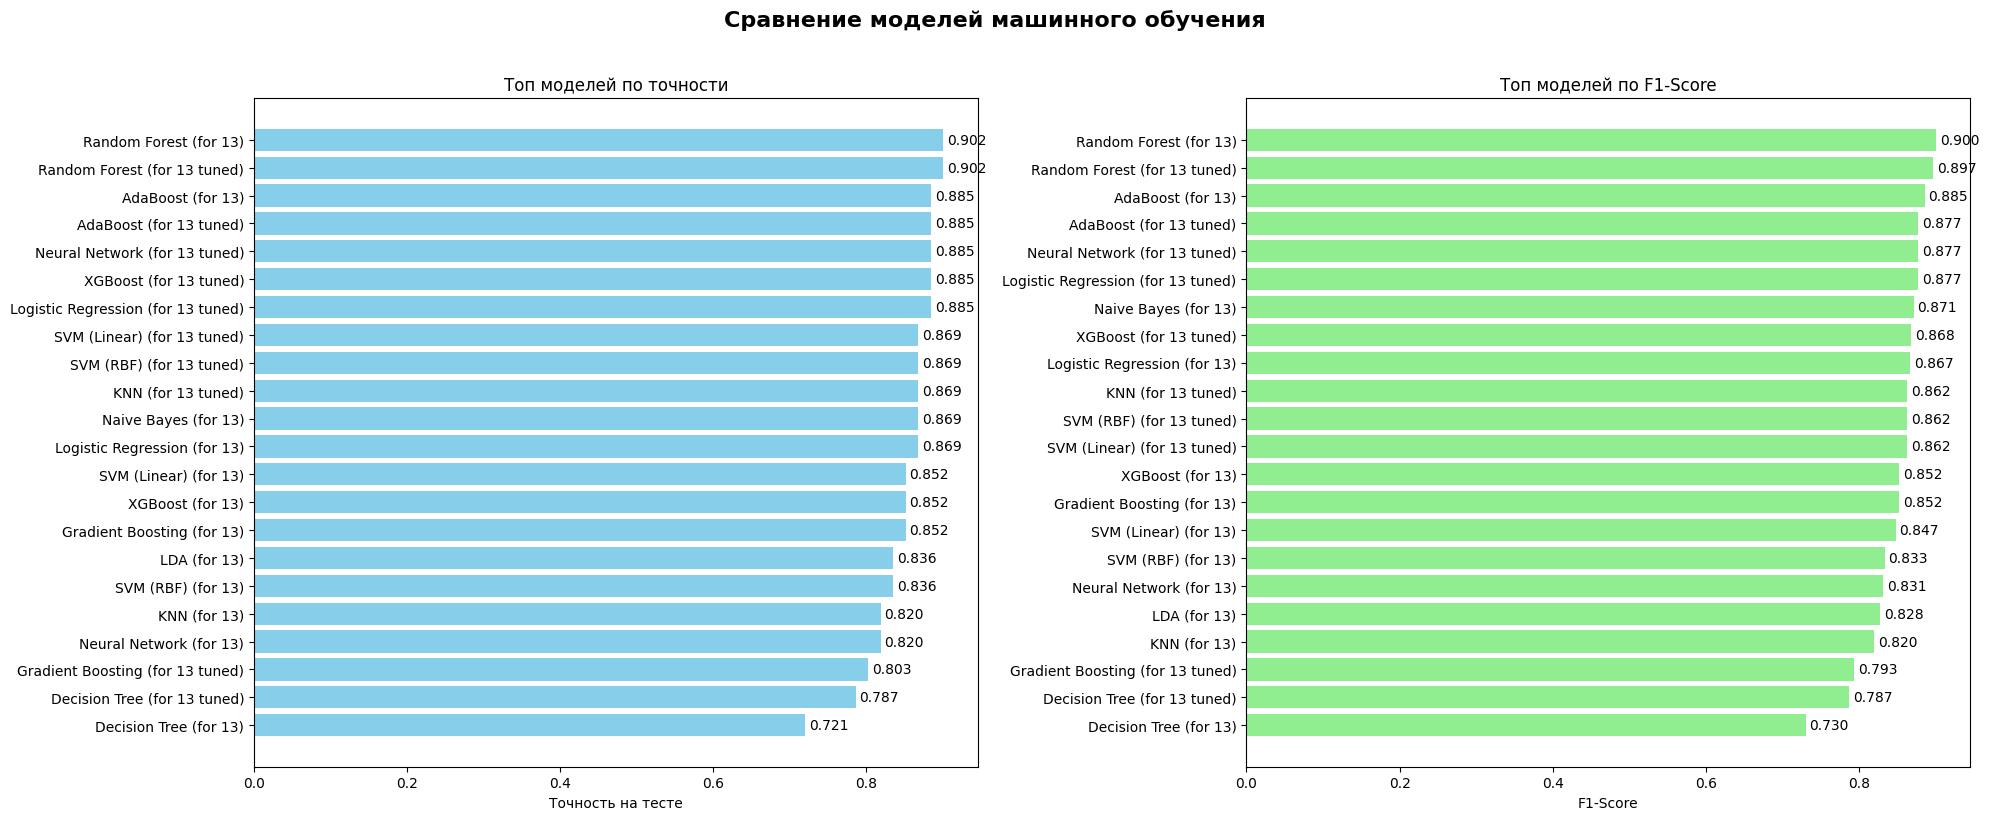

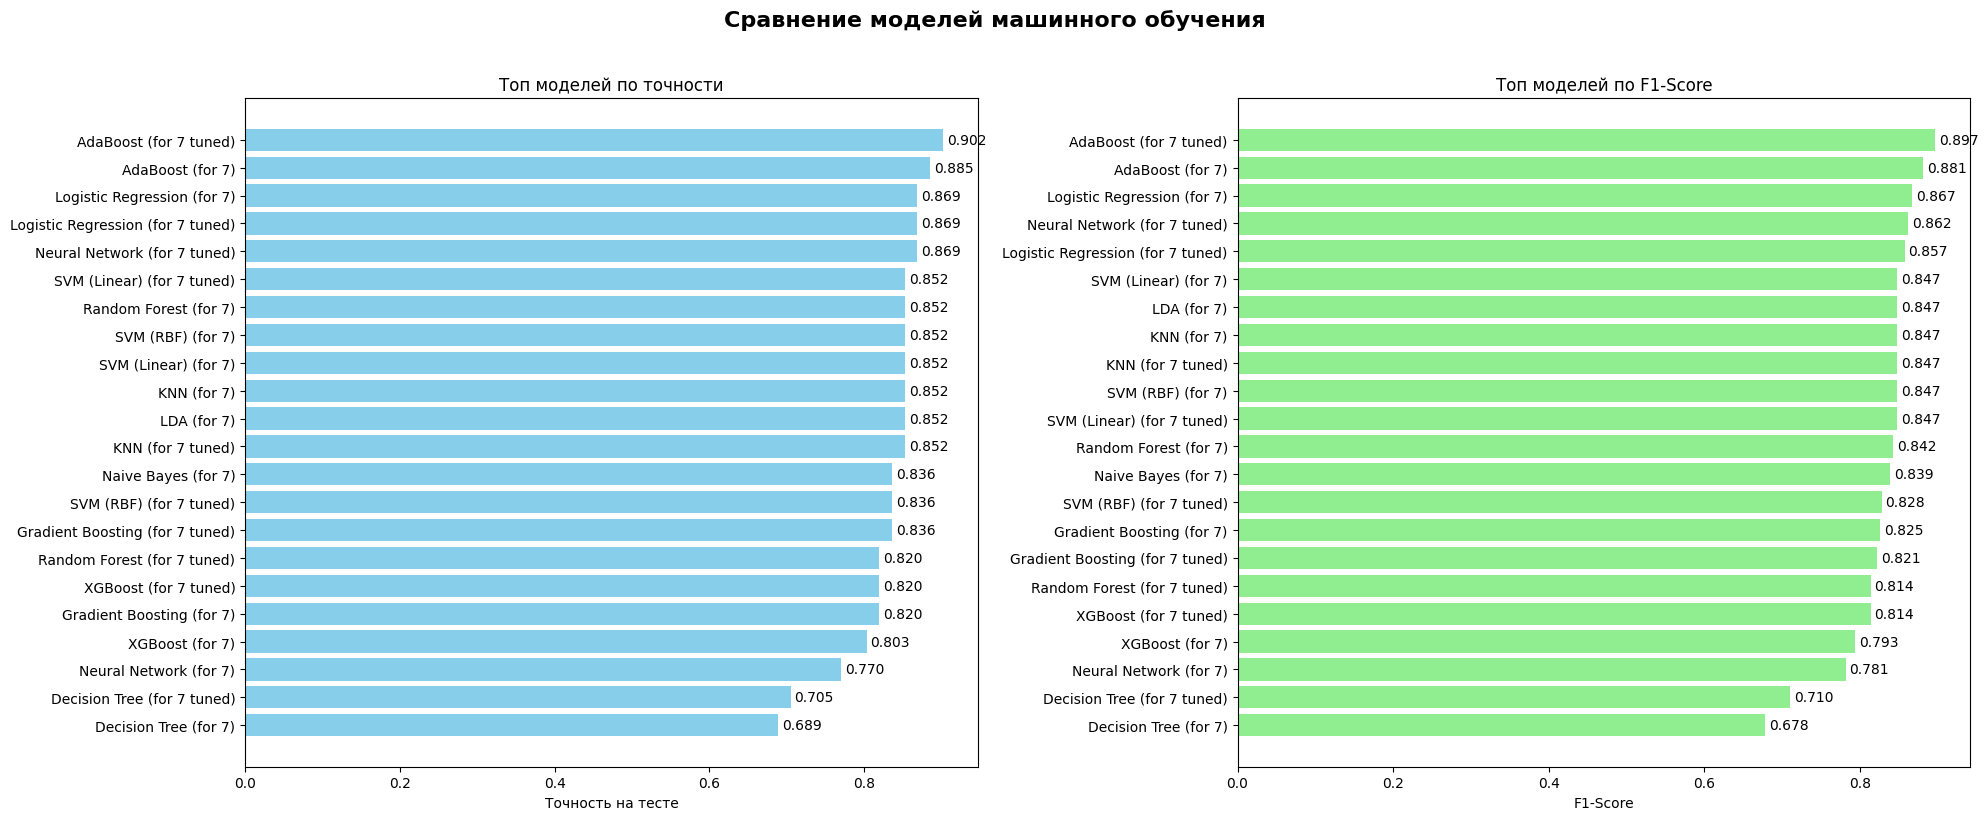

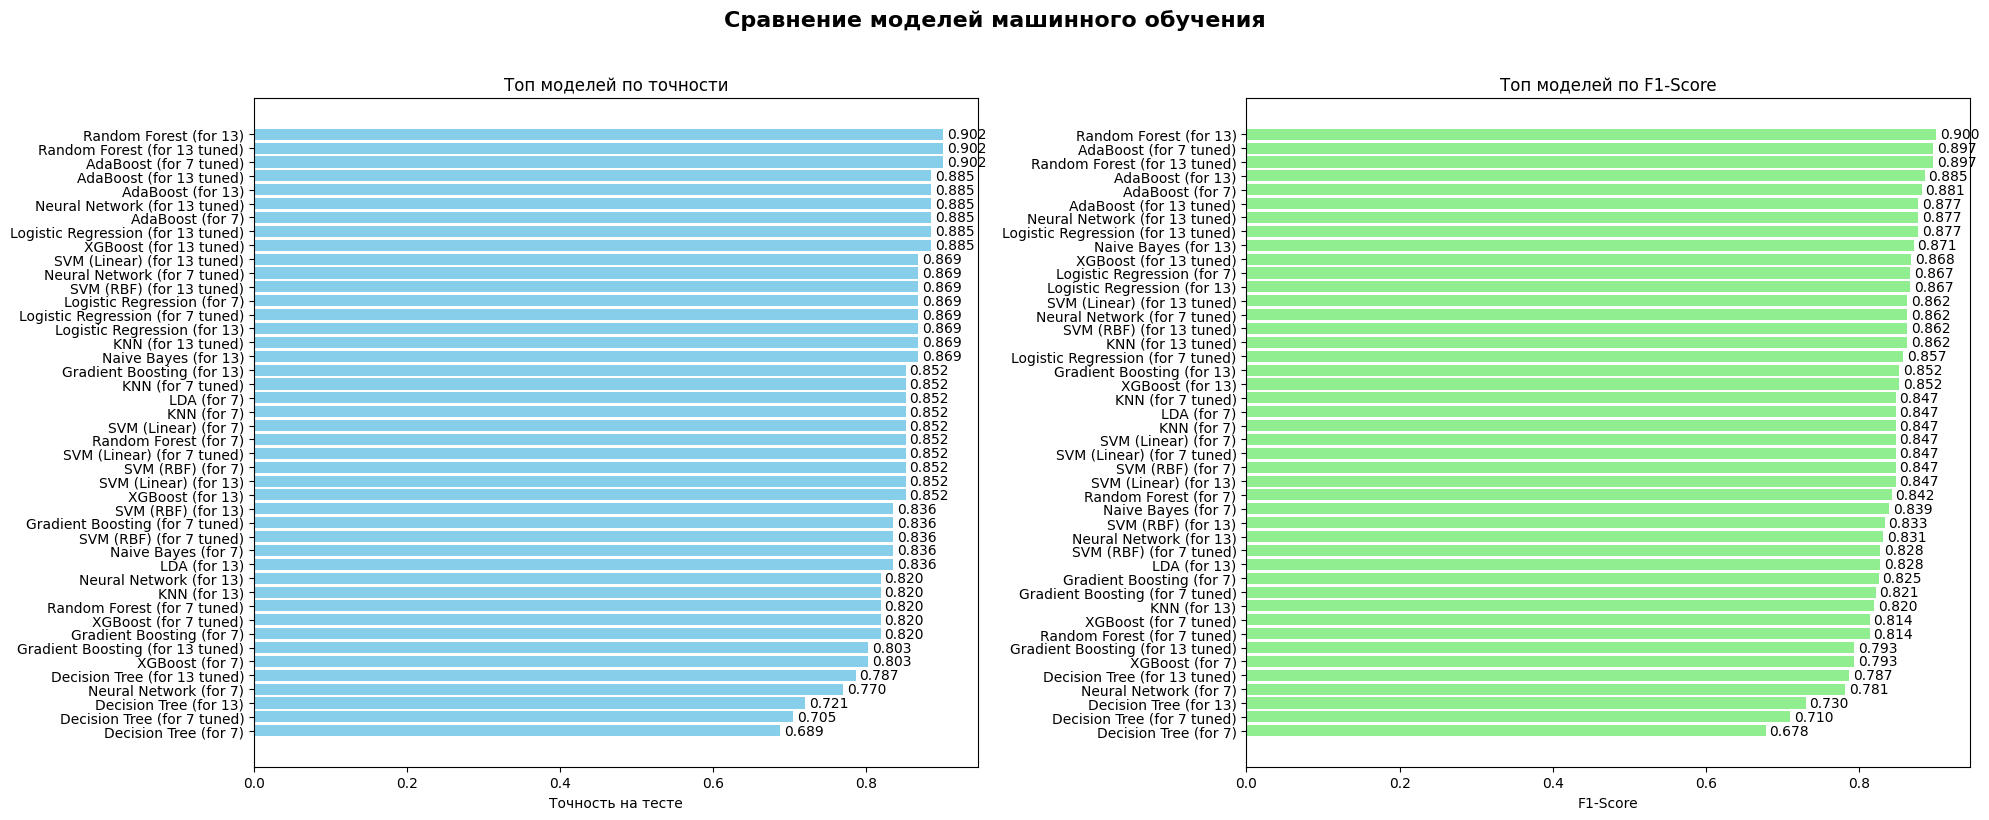

In [93]:
output_models(combined_results_13)
output_models(combined_results_7)
output_models(combined_results)

___
___
# 9. Сравнение моделей до и после настройки
___

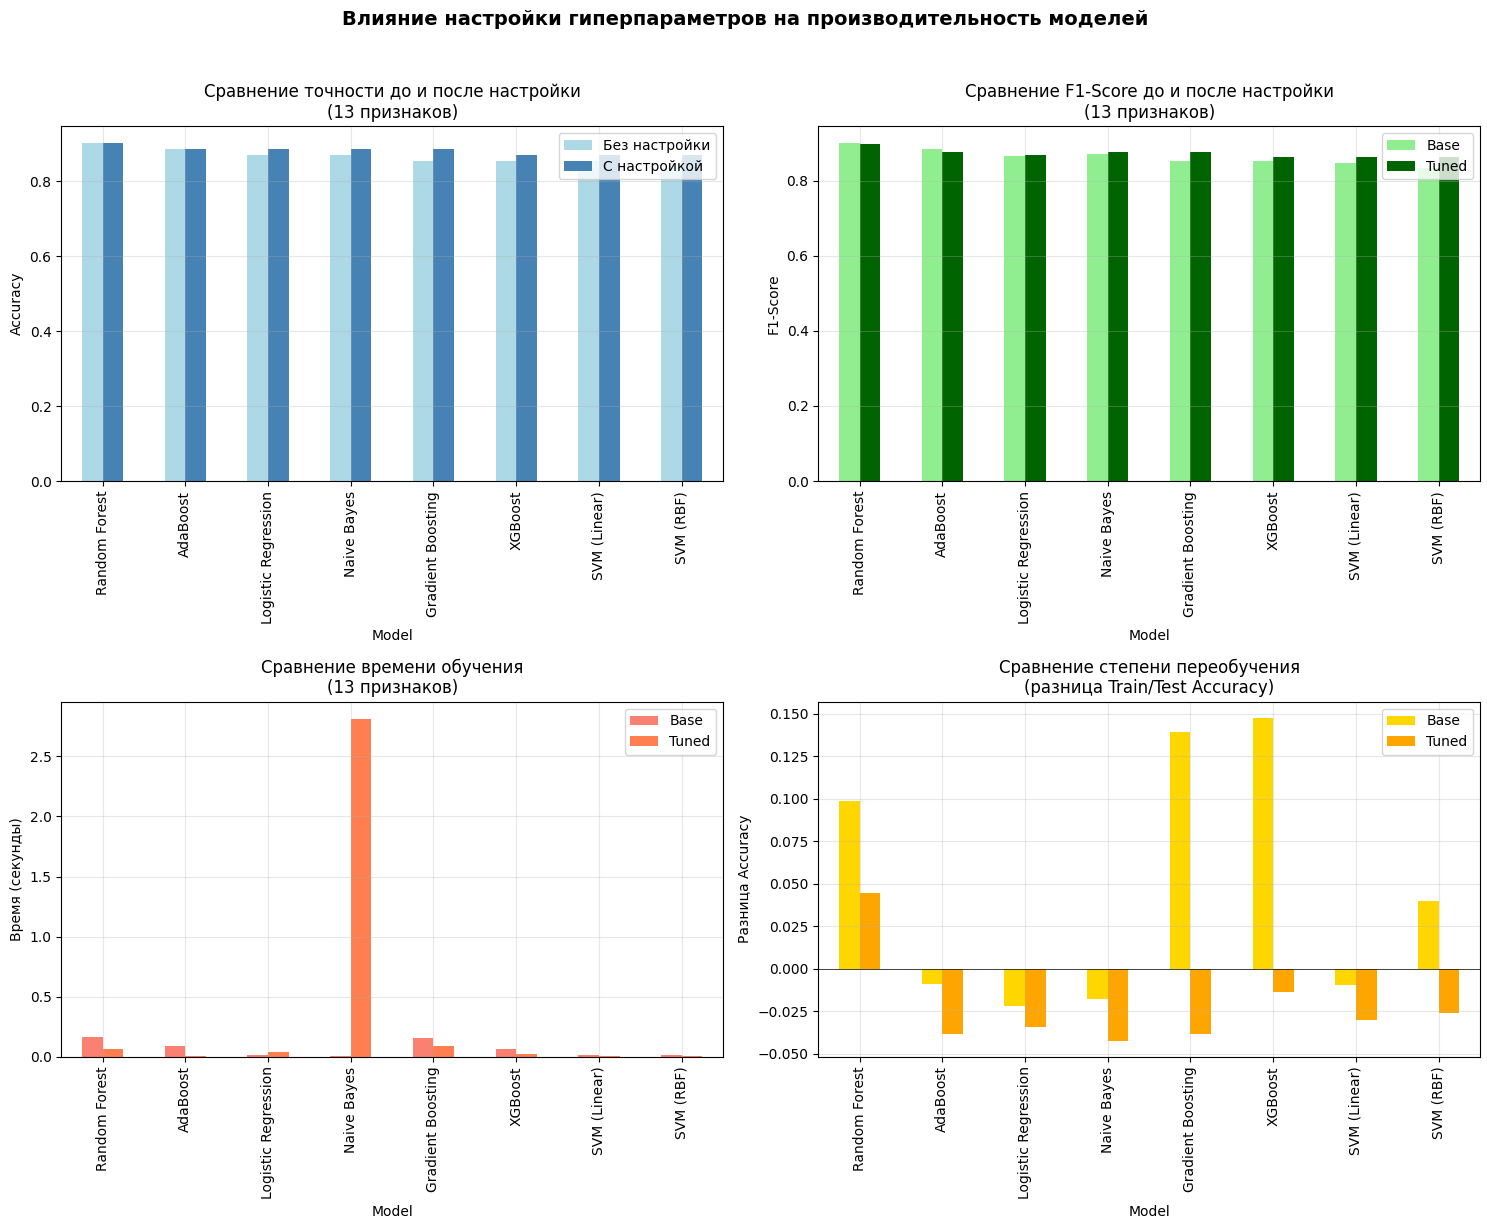

In [94]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Сравнение точности
models_comparison = pd.DataFrame({
    'Base': results_13_df['Test Accuracy'].values[:8],
    'Tuned': results_13_tuned_df['Test Accuracy'].values[:8]
}, index=results_13_df['Model'].str.replace(' (for 13)', '')[:8])

models_comparison.plot(kind='bar', ax=axes[0,0], color=['lightblue', 'steelblue'])
axes[0,0].set_title('Сравнение точности до и после настройки\n(13 признаков)')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend(['Без настройки', 'С настройкой'])
axes[0,0].grid(True, alpha=0.3)

# F1-Score сравнение
f1_comparison = pd.DataFrame({
    'Base': results_13_df['F1-Score'].values[:8],
    'Tuned': results_13_tuned_df['F1-Score'].values[:8]
}, index=results_13_df['Model'].str.replace(' (for 13)', '')[:8])

f1_comparison.plot(kind='bar', ax=axes[0,1], color=['lightgreen', 'darkgreen'])
axes[0,1].set_title('Сравнение F1-Score до и после настройки\n(13 признаков)')
axes[0,1].set_ylabel('F1-Score')
axes[0,1].grid(True, alpha=0.3)

# Время обучения
time_comparison = pd.DataFrame({
    'Base': results_13_df['Time (s)'].values[:8],
    'Tuned': results_13_tuned_df['Time (s)'].values[:8]
}, index=results_13_df['Model'].str.replace(' (for 13)', '')[:8])

time_comparison.plot(kind='bar', ax=axes[1,0], color=['salmon', 'coral'])
axes[1,0].set_title('Сравнение времени обучения\n(13 признаков)')
axes[1,0].set_ylabel('Время (секунды)')
axes[1,0].grid(True, alpha=0.3)

# Переобучение
overfitting_comparison = pd.DataFrame({
    'Base': results_13_df['Overfitting'].values[:8],
    'Tuned': results_13_tuned_df['Overfitting'].values[:8]
}, index=results_13_df['Model'].str.replace(' (for 13)', '')[:8])

overfitting_comparison.plot(kind='bar', ax=axes[1,1], color=['gold', 'orange'])
axes[1,1].set_title('Сравнение степени переобучения\n(разница Train/Test Accuracy)')
axes[1,1].set_ylabel('Разница Accuracy')
axes[1,1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Влияние настройки гиперпараметров на производительность моделей', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

___
___
# 10. Анализ важности признаков
___


10. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

10.1. ВАЖНОСТЬ ПРИЗНАКОВ (13 признаков):
----------------------------------------
 1. thalach        : 0.1354
 2. cp             : 0.1272
 3. thal           : 0.1229
 4. ca             : 0.1008
 5. age            : 0.0913
 6. oldpeak        : 0.0894
 7. chol           : 0.0887
 8. trestbps       : 0.0807
 9. exang          : 0.0507
10. slope          : 0.0466
11. sex            : 0.0359
12. restecg        : 0.0184
13. fbs            : 0.0119


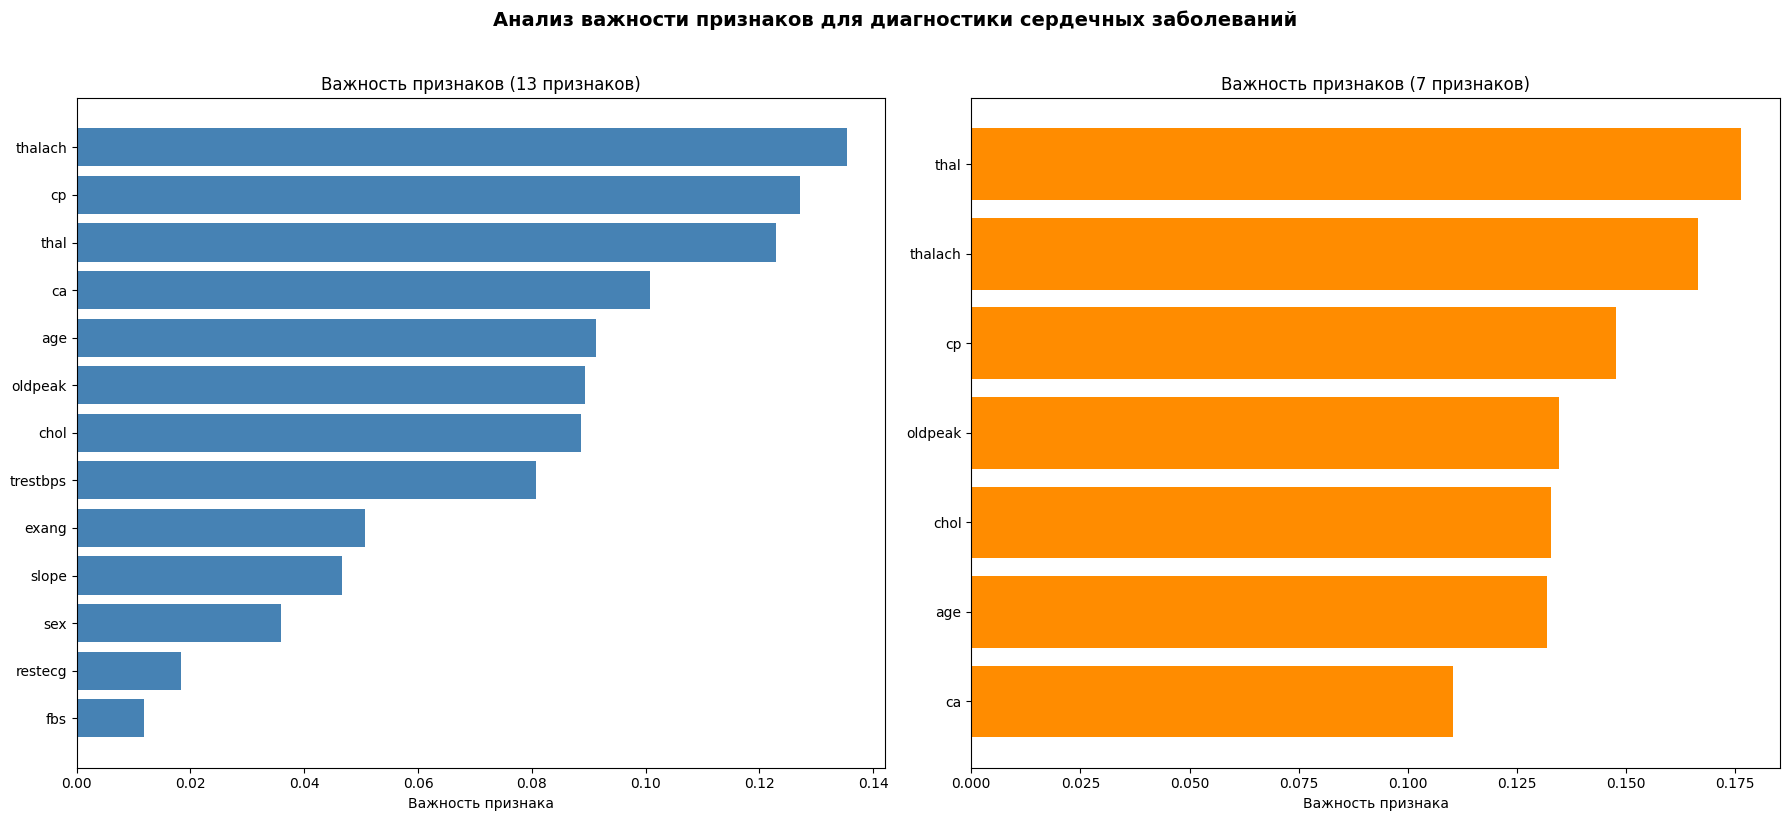

In [95]:
print("\n" + "="*80)
print("10. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("="*80)

# Обучим Random Forest для анализа важности признаков
rf_13 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_13.fit(X_13_train, y_13_train)

# Важность признаков для 13 признаков
feature_importance_13 = pd.DataFrame({
    'Feature': all_13_features,
    'Importance': rf_13.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n10.1. ВАЖНОСТЬ ПРИЗНАКОВ (13 признаков):")
print("-" * 40)
for i, (feature, importance) in enumerate(zip(feature_importance_13['Feature'], 
                                              feature_importance_13['Importance']), 1):
    print(f"{i:2}. {feature:15}: {importance:.4f}")

# Визуализация важности признаков
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Для 13 признаков
axes[0].barh(range(len(feature_importance_13)), 
            feature_importance_13['Importance'], 
            color='steelblue')
axes[0].set_yticks(range(len(feature_importance_13)))
axes[0].set_yticklabels(feature_importance_13['Feature'])
axes[0].set_xlabel('Важность признака')
axes[0].set_title('Важность признаков (13 признаков)')
axes[0].invert_yaxis()

# Для 7 признаков
rf_7 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_7.fit(X_7_train, y_7_train)

feature_importance_7 = pd.DataFrame({
    'Feature': all_7_features,
    'Importance': rf_7.feature_importances_
}).sort_values('Importance', ascending=False)

axes[1].barh(range(len(feature_importance_7)), 
            feature_importance_7['Importance'], 
            color='darkorange')
axes[1].set_yticks(range(len(feature_importance_7)))
axes[1].set_yticklabels(feature_importance_7['Feature'])
axes[1].set_xlabel('Важность признака')
axes[1].set_title('Важность признаков (7 признаков)')
axes[1].invert_yaxis()

plt.suptitle('Анализ важности признаков для диагностики сердечных заболеваний', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

___
___
# 11. Детальный анализ лучшей модели
___


11. ДЕТАЛЬНЫЙ АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ

ЛУЧШАЯ МОДЕЛЬ ПО КОМПЛЕКСНОМУ РЕЙТИНГУ:
----------------------------------------
Модель: Random Forest (for 13 tuned)
Комплексный рейтинг: 0.9167
Точность: 0.902
F1-Score: 0.897
ROC-AUC: 0.958
Переобучение: 0.045
Время обучения: 0.065 сек

Используется 13 признаков
Тип модели: настроенная

СРАВНЕНИЕ С ДРУГИМИ ТОП-МОДЕЛЯМИ:
----------------------------------------
→ 1. Random Forest (for 13 tuned)   | Точность: 0.902 | F1: 0.897 | AUC: 0.958 | Время: 0.065с
  2. AdaBoost (for 7 tuned)         | Точность: 0.902 | F1: 0.897 | AUC: 0.955 | Время: 0.375с
  3. AdaBoost (for 13)              | Точность: 0.885 | F1: 0.885 | AUC: 0.968 | Время: 0.088с
  4. Random Forest (for 13)         | Точность: 0.902 | F1: 0.900 | AUC: 0.954 | Время: 0.168с
  5. AdaBoost (for 7)               | Точность: 0.885 | F1: 0.881 | AUC: 0.966 | Время: 0.084с

АНАЛИЗ КОМПРОМИССОВ:
----------------------------------------
Лучшая по точности: Random Forest (for 13) (0.902)
Самая бы

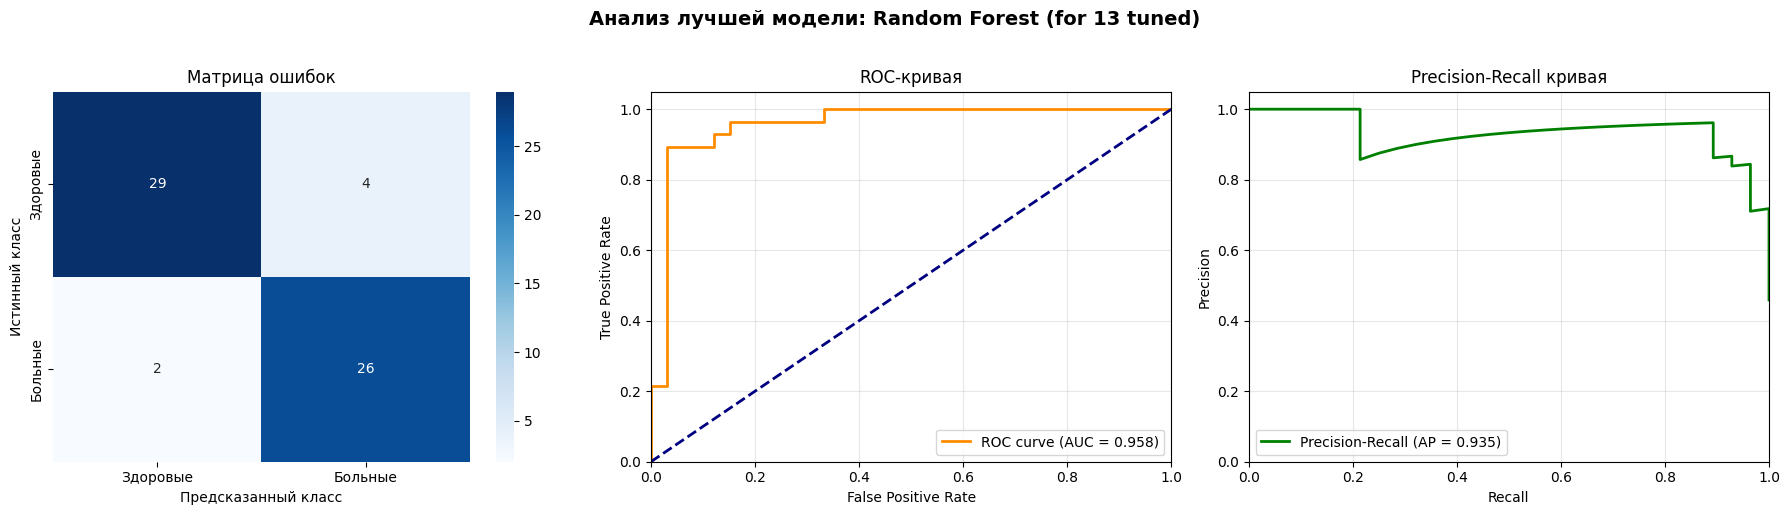

In [96]:
print("\n" + "="*80)
print("11. ДЕТАЛЬНЫЙ АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ")
print("="*80)

# Создаем комплексный рейтинг моделей
combined_results['Composite_Score'] = (
    combined_results['Test Accuracy'] * 0.4 + 
    combined_results['F1-Score'] * 0.3 + 
    combined_results['ROC-AUC'].fillna(0) * 0.2 +
    (1 - combined_results['Overfitting'].abs()) * 0.1
)

# Находим лучшую модель по комплексному рейтингу
best_model_row = combined_results.loc[combined_results['Composite_Score'].idxmax()]
best_model_name = best_model_row['Model']
best_composite_score = best_model_row['Composite_Score']

print(f"\nЛУЧШАЯ МОДЕЛЬ ПО КОМПЛЕКСНОМУ РЕЙТИНГУ:")
print("-" * 40)
print(f"Модель: {best_model_name}")
print(f"Комплексный рейтинг: {best_composite_score:.4f}")
print(f"Точность: {best_model_row['Test Accuracy']:.3f}")
print(f"F1-Score: {best_model_row['F1-Score']:.3f}")
print(f"ROC-AUC: {best_model_row['ROC-AUC']:.3f}")
print(f"Переобучение: {best_model_row['Overfitting']:.3f}")
print(f"Время обучения: {best_model_row['Time (s)']:.3f} сек")

# Определяем, какая конфигурация признаков использовалась
if 'for 13' in best_model_name:
    print(f"\nИспользуется 13 признаков")
    # Определяем, какая конкретно модель (базовая или настроенная)
    model_type = "базовая" if "tuned" not in best_model_name else "настроенная"
    print(f"Тип модели: {model_type}")
    
elif 'for 7' in best_model_name:
    print(f"\nИспользуется 7 признаков")
    model_type = "базовая" if "tuned" not in best_model_name else "настроенная"
    print(f"Тип модели: {model_type}")

# Сравнение с другими топ-моделями
print(f"\nСРАВНЕНИЕ С ДРУГИМИ ТОП-МОДЕЛЯМИ:")
print("-" * 40)
top_5_models = combined_results.nlargest(5, 'Composite_Score')
for i, (_, row) in enumerate(top_5_models.iterrows(), 1):
    marker = "→ " if row['Model'] == best_model_name else "  "
    print(f"{marker}{i}. {row['Model']:30} "
          f"| Точность: {row['Test Accuracy']:.3f} "
          f"| F1: {row['F1-Score']:.3f} "
          f"| AUC: {row['ROC-AUC']:.3f} "
          f"| Время: {row['Time (s)']:.3f}с")

# Анализ компромиссов
print(f"\nАНАЛИЗ КОМПРОМИССОВ:")
print("-" * 40)

# Найдем лучшую модель по точности
best_accuracy_model = combined_results.loc[combined_results['Test Accuracy'].idxmax()]
print(f"Лучшая по точности: {best_accuracy_model['Model']} ({best_accuracy_model['Test Accuracy']:.3f})")

# Найдем самую быструю модель среди точных (точность > 0.85)
fast_accurate_models = combined_results[combined_results['Test Accuracy'] > 0.85]
if len(fast_accurate_models) > 0:
    fastest_model = fast_accurate_models.loc[fast_accurate_models['Time (s)'].idxmin()]
    print(f"Самая быстрая (точность >85%): {fastest_model['Model']} "
          f"({fastest_model['Time (s)']:.3f} сек, точность: {fastest_model['Test Accuracy']:.3f})")

# Визуализация лучшей модели
print(f"\n11.1. ОТЧЕТ КЛАССИФИКАЦИИ ДЛЯ ЛУЧШЕЙ МОДЕЛИ:")
print("-" * 40)

# Определяем, какая модель является лучшей
if 'Random Forest' in best_model_name and 'for 13' in best_model_name:
    if 'tuned' in best_model_name:
        best_model = RandomForestClassifier(
            bootstrap=False, max_depth=None, max_features='sqrt',
            min_samples_leaf=4, min_samples_split=10, 
            n_estimators=50, random_state=42
        )
    else:
        best_model = RandomForestClassifier(random_state=42)
    best_model.fit(X_13_train, y_13_train)
    y_pred = best_model.predict(X_13_test)
    y_pred_proba = best_model.predict_proba(X_13_test)[:, 1]
    y_test = y_13_test
elif 'Random Forest' in best_model_name and 'for 7' in best_model_name:
    if 'tuned' in best_model_name:
        best_model = RandomForestClassifier(
            bootstrap=True, max_depth=None, max_features=None,
            min_samples_leaf=4, min_samples_split=10,
            n_estimators=300, random_state=42
        )
    else:
        best_model = RandomForestClassifier(random_state=42)
    best_model.fit(X_7_train, y_7_train)
    y_pred = best_model.predict(X_7_test)
    y_pred_proba = best_model.predict_proba(X_7_test)[:, 1]
    y_test = y_7_test

print(classification_report(y_test, y_pred, target_names=['Здоровые', 'Больные']))

print("\n11.2. MATRIЦА ОШИБОК (CONFUSION MATRIX):")
print("-" * 40)
cm = confusion_matrix(y_test, y_pred)
print(f"Истинные отрицательные (TN): {cm[0,0]} - правильно предсказанные здоровые")
print(f"Ложные положительные (FP): {cm[0,1]} - здоровые, ошибочно предсказанные как больные")
print(f"Ложные отрицательные (FN): {cm[1,0]} - больные, ошибочно предсказанные как здоровые")
print(f"Истинные положительные (TP): {cm[1,1]} - правильно предсказанные больные")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Матрица ошибок
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Здоровые', 'Больные'],
            yticklabels=['Здоровые', 'Больные'], 
            ax=axes[0])
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')
axes[0].set_title('Матрица ошибок')

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, 
            label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-кривая')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

# Precision-Recall кривая
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

axes[2].plot(recall, precision, color='green', lw=2,
            label=f'Precision-Recall (AP = {avg_precision:.3f})')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall кривая')
axes[2].legend(loc="lower left")
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Анализ лучшей модели: {best_model_name}', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()